# Airbus 1 m Random Forest Land-Cover Classifier

Trains, validates, assesses, and applies a `scikit-learn` Random Forest classifier to a four-band, 1 m Airbus image, following `random_forest_airbus_classifier_plan.md`.

Requires `uv sync` to have installed this project (including `config.py`) into the active environment.

## 1. Configuration

In [1]:
import json
import logging
from pathlib import Path

import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterio.windows
from rasterio.enums import Resampling
from rasterio.warp import calculate_default_transform, reproject
from rasterio.features import rasterize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, confusion_matrix, precision_recall_fscore_support

In [2]:
try:
    import config
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "config module not found -- run `uv sync` from the repo root to install this "
        "project (including config.py) into the environment."
    ) from exc

Raw inputs (the Airbus mosaic and training GeoPackage) are multi-GB and live outside the repo on the analyst's machine, so their paths are set here rather than in `config.py`. Everything else -- the class schema, Random Forest parameters, and NoData values -- is shared project-wide config.

In [3]:
AIRBUS_RASTER_PATH = Path(
    "/Users/chris/Desktop/Projects/CERK/Enerau/enarau_hab_class/"
    "airbus_mosaic_cloud_masked_2.tif"
)
TRAINING_GPKG_PATH = Path(
    "/Users/chris/Desktop/Projects/CERK/Enerau/enarau_hab_class/"
    "hab_class_training_sample_polygons_final.gpkg"
)
TRAINING_LAYER = "hab_class_training_sample_polygons_final"

OUTPUT_DIR = config.RF_CLASSIFIER_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = config.RF_RANDOM_SEED
TEST_FRACTION = config.RF_TEST_FRACTION
MAX_PIXELS_PER_POLYGON = config.RF_MAX_PIXELS_PER_POLYGON
RF_PARAMS = config.RF_PARAMS
RASTER_NODATA = config.RF_RASTER_NODATA
CLASSIFICATION_NODATA = config.RF_CLASSIFICATION_NODATA
CLASS_LABELS = config.RF_CLASS_LABELS  # {class_id: class_name}, training/model schema
CLASS_ORDER = sorted(CLASS_LABELS)  # fixed class order for confusion matrices

# Final delivered schema: cultivated_a/cultivated_b (4, 5) collapse into a single
# "cultivated" class so the delivered map matches the original 7-class scheme.
FINAL_CLASS_LABELS = config.RF_FINAL_CLASS_LABELS
CLASS_REMAP = config.RF_CLASS_REMAP  # training class_id -> final delivered class_id

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger("rf_airbus_classifier")

## 2. Load and Validate the Training Data

In [4]:
def load_and_validate_training_data(gpkg_path, layer, class_labels):
    """Load training polygons and enforce the plan's required-field and class-schema checks."""
    gdf = gpd.read_file(gpkg_path, layer=layer)

    required_fields = {"sample_id", "class_id", "class_name"}
    missing_fields = required_fields.difference(gdf.columns)
    if missing_fields:
        raise ValueError(f"Training layer is missing required fields: {sorted(missing_fields)}")

    errors = []

    null_sample_ids = gdf["sample_id"].isna() | (
        gdf["sample_id"].astype("string").str.strip() == ""
    )
    if null_sample_ids.any():
        errors.append(f"{int(null_sample_ids.sum())} feature(s) have a null/blank sample_id")

    duplicate_sample_ids = gdf["sample_id"].duplicated(keep=False)
    if duplicate_sample_ids.any():
        dupes = sorted(gdf.loc[duplicate_sample_ids, "sample_id"].unique())
        errors.append(f"Duplicate sample_id values: {dupes}")

    class_ids = pd.to_numeric(gdf["class_id"], errors="coerce")
    non_integer = class_ids.isna() | (class_ids != class_ids.round())
    out_of_range = ~class_ids.isin(class_labels)
    if (non_integer | out_of_range).any():
        bad = gdf.loc[non_integer | out_of_range, ["sample_id", "class_id"]]
        errors.append(f"class_id values outside {sorted(class_labels)} or non-integer:\n{bad.to_string(index=False)}")

    expected_names = class_ids.map(class_labels)
    name_mismatch = (
        gdf["class_name"].astype("string").str.strip() != expected_names
    ) & expected_names.notna()
    if name_mismatch.any():
        bad = gdf.loc[name_mismatch, ["sample_id", "class_id", "class_name"]]
        errors.append(f"class_name does not match expected label for class_id:\n{bad.to_string(index=False)}")

    invalid_geom_type = ~gdf.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    if invalid_geom_type.any():
        bad_ids = gdf.loc[invalid_geom_type, "sample_id"].tolist()
        errors.append(f"{int(invalid_geom_type.sum())} feature(s) are not Polygon/MultiPolygon: {bad_ids}")

    empty_geometry = gdf.geometry.is_empty
    if empty_geometry.any():
        bad_ids = gdf.loc[empty_geometry, "sample_id"].tolist()
        errors.append(f"{int(empty_geometry.sum())} feature(s) have empty geometry: {bad_ids}")

    invalid_geometry = ~gdf.geometry.is_valid
    if invalid_geometry.any():
        bad_ids = gdf.loc[invalid_geometry, "sample_id"].tolist()
        errors.append(f"{int(invalid_geometry.sum())} feature(s) have invalid geometry: {bad_ids}")

    if errors:
        raise ValueError("Training-data validation failed:\n" + "\n".join(f"- {e}" for e in errors))

    logger.info(
        "Training data validated: %d polygons across %d classes", len(gdf), gdf["class_id"].nunique()
    )
    return gdf

In [5]:
training_gdf = load_and_validate_training_data(TRAINING_GPKG_PATH, TRAINING_LAYER, CLASS_LABELS)
training_gdf["class_id"].value_counts().sort_index()

2026-07-26 23:41:55,003 INFO Training data validated: 2545 polygons across 8 classes


class_id
1     144
2     156
3     207
4      49
5      97
6     208
7     112
8    1572
Name: count, dtype: int64

## 3. Read Raster Metadata

In [6]:
def read_raster_metadata(raster_path):
    """Record the Airbus raster's structure; the four bands are the predictor variables as-is
    (Random Forest needs no band scaling/normalization)."""
    with rasterio.open(raster_path) as src:
        if src.count != 4:
            raise ValueError(f"Expected a four-band raster, found {src.count} bands: {raster_path}")
        metadata = {
            "band_count": src.count,
            "width": src.width,
            "height": src.height,
            "transform": src.transform,
            "crs": src.crs,
            "profile": src.profile.copy(),
            "nodata": src.nodata,
            "block_shapes": src.block_shapes,
        }
    logger.info(
        "Raster metadata: %d bands, %dx%d px, CRS=%s, nodata=%s",
        metadata["band_count"], metadata["width"], metadata["height"], metadata["crs"], metadata["nodata"],
    )
    return metadata

In [7]:
raster_metadata = read_raster_metadata(AIRBUS_RASTER_PATH)
raster_metadata

2026-07-26 23:41:55,060 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_database: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:41:55,060 WARNING CPLE_AppDefined in The definition of projected CRS EPSG:32736 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


2026-07-26 23:41:55,060 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


ERROR 1: PROJ: internal_proj_identify: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.
2026-07-26 23:41:55,071 INFO Raster metadata: 4 bands, 13460x12220 px, CRS=PROJCS["WGS 84 / UTM zone 36S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",33],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], nodata=65535.0


{'band_count': 4,
 'width': 13460,
 'height': 12220,
 'transform': Affine(1.0, 0.0, 750920.0,
        0.0, -1.0, 9890130.0),
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 36S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",33],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'profile': {'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 65535.0, 'width': 13460, 'height': 12220, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 36S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION[

## 4. Extract Training Pixels

In [8]:
def _clip_window(window, raster_width, raster_height):
    """Clamp a polygon's bounding window to the raster extent (defensive; training polygons
    are assumed to lie over valid image pixels, but edge/boundary polygons can still clip)."""
    col_off = max(0, window.col_off)
    row_off = max(0, window.row_off)
    col_end = min(raster_width, window.col_off + window.width)
    row_end = min(raster_height, window.row_off + window.height)
    return rasterio.windows.Window(col_off, row_off, max(col_end - col_off, 0), max(row_end - row_off, 0))

In [9]:
def extract_training_pixels(raster_path, gdf, max_pixels_per_polygon, nodata_value, seed):
    """Extract band values at pixel centers falling inside each training polygon (no
    all-touched rasterization), drop NoData rows, and cap pixels per polygon.

    Polygons are processed in sample_id order with a single seeded RNG, so pixel sampling is
    reproducible regardless of GeoDataFrame row order.
    """
    rng = np.random.default_rng(seed)
    rows = []

    with rasterio.open(raster_path) as src:
        if gdf.crs != src.crs:
            # Observed in practice: the training GeoPackage is EPSG:32737, the raster is
            # EPSG:32736 -- reproject the vectors to the raster's CRS rather than assume a match.
            logger.warning("Reprojecting training polygons from %s to raster CRS %s", gdf.crs, src.crs)
            gdf = gdf.to_crs(src.crs)

        for _, feature in gdf.sort_values("sample_id").iterrows():
            geom = feature.geometry

            raw_window = rasterio.windows.from_bounds(*geom.bounds, transform=src.transform)
            col_off = int(np.floor(raw_window.col_off))
            row_off = int(np.floor(raw_window.row_off))
            col_end = int(np.ceil(raw_window.col_off + raw_window.width))
            row_end = int(np.ceil(raw_window.row_off + raw_window.height))
            window = rasterio.windows.Window(col_off, row_off, col_end - col_off, row_end - row_off)
            window = _clip_window(window, src.width, src.height)

            if window.width <= 0 or window.height <= 0:
                logger.warning("Polygon %s does not intersect the raster; skipping", feature["sample_id"])
                continue

            win_transform = rasterio.windows.transform(window, src.transform)
            # all_touched=False rasterizes using GDAL's default pixel-center-in-polygon rule.
            mask = rasterize(
                [(geom, 1)],
                out_shape=(int(window.height), int(window.width)),
                transform=win_transform,
                fill=0,
                all_touched=False,
                dtype="uint8",
            ).astype(bool)

            if not mask.any():
                logger.warning("Polygon %s produced no pixel centers; skipping", feature["sample_id"])
                continue

            block = src.read(window=window)  # (4, height, width)
            values = block[:, mask].T  # (n_pixels, 4)

            valid = ~np.any(values == nodata_value, axis=1)
            values = values[valid]

            if values.shape[0] == 0:
                logger.warning("Polygon %s has no valid (non-NoData) pixels; skipping", feature["sample_id"])
                continue

            if values.shape[0] > max_pixels_per_polygon:
                keep = rng.choice(values.shape[0], size=max_pixels_per_polygon, replace=False)
                values = values[keep]

            for row in values:
                rows.append((*row, feature["class_id"], feature["class_name"], feature["sample_id"]))

    if not rows:
        raise ValueError("No training pixels were extracted from any polygon.")

    columns = ["band_1", "band_2", "band_3", "band_4", "class_id", "class_name", "sample_id"]
    pixel_df = pd.DataFrame(rows, columns=columns)

    logger.info(
        "Extracted %d training pixels from %d polygons", len(pixel_df), pixel_df["sample_id"].nunique()
    )
    return pixel_df

In [10]:
pixel_df = extract_training_pixels(
    AIRBUS_RASTER_PATH, training_gdf, MAX_PIXELS_PER_POLYGON, RASTER_NODATA, RANDOM_SEED
)

FEATURE_COLUMNS = ["band_1", "band_2", "band_3", "band_4"]
pixel_df.shape

2026-07-26 23:41:55,146 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_database: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:41:55,146 WARNING CPLE_AppDefined in The definition of projected CRS EPSG:32736 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


2026-07-26 23:41:55,146 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:41:55,163 INFO GDAL signalled an error: err_no=1, msg='PROJ: internal_proj_identify: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.'


2026-07-26 23:41:55,159 WARNING Reprojecting training polygons from EPSG:32737 to raster CRS PROJCS["WGS 84 / UTM zone 36S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",33],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


2026-07-26 23:41:55,760 WARNING Polygon built_1195 has no valid (non-NoData) pixels; skipping


2026-07-26 23:41:55,762 WARNING Polygon built_1200 has no valid (non-NoData) pixels; skipping


2026-07-26 23:41:56,958 WARNING Polygon water_2383 produced no pixel centers; skipping


2026-07-26 23:41:57,175 INFO Extracted 135024 training pixels from 2542 polygons


(135024, 7)

## 5. Produce a Training-Sample Inventory

In [11]:
def build_sample_inventory(pixel_df, class_labels):
    """Per-class polygon/pixel counts, for reviewing class balance before splitting."""
    polygon_counts = (
        pixel_df.groupby(["class_id", "sample_id"]).size().rename("pixel_count").reset_index()
    )

    rows = []
    for class_id, label in sorted(class_labels.items()):
        class_polys = polygon_counts[polygon_counts["class_id"] == class_id]
        rows.append(
            {
                "class_id": class_id,
                "class_name": label,
                "n_polygons": len(class_polys),
                "n_pixels": int(class_polys["pixel_count"].sum()),
                "min_pixels_per_polygon": int(class_polys["pixel_count"].min()) if len(class_polys) else 0,
                "max_pixels_per_polygon": int(class_polys["pixel_count"].max()) if len(class_polys) else 0,
                "median_pixels_per_polygon": float(class_polys["pixel_count"].median()) if len(class_polys) else 0,
            }
        )
    inventory = pd.DataFrame(rows)

    missing_classes = inventory.loc[inventory["n_polygons"] == 0, "class_name"].tolist()
    if missing_classes:
        logger.warning("Classes with zero extracted polygons: %s", missing_classes)

    return inventory

In [12]:
sample_inventory = build_sample_inventory(pixel_df, CLASS_LABELS)
sample_inventory.to_csv(OUTPUT_DIR / "training_sample_inventory.csv", index=False)
sample_inventory

,class_id,class_name,n_polygons,n_pixels,min_pixels_per_polygon,max_pixels_per_polygon,median_pixels_per_polygon
0,1,dense_forest,144,20695,17,150,150.0
1,2,bareground,156,18665,19,150,150.0
2,3,grassland,207,30382,3,150,150.0
3,4,cultivated_a,49,7350,150,150,150.0
4,5,cultivated_b,97,14550,150,150,150.0
5,6,shrubland,208,27838,11,150,150.0
6,7,water,111,9033,1,150,96.0
7,8,built,1570,6511,1,150,4.0


Review the inventory above for missing classes, severe class imbalance, or classes dominated by only a few polygons before continuing.

## 6. Create a Grouped Train/Test Split

In [13]:
def grouped_train_test_split(pixel_df, test_fraction, seed):
    """Split polygons (not pixels) into train/test so all pixels from one polygon stay
    together, constructing the split by class so every class is guaranteed to appear in both
    partitions -- the plan's own fallback for when a stratified grouped split can't otherwise
    guarantee this."""
    polygons = pixel_df[["sample_id", "class_id"]].drop_duplicates().reset_index(drop=True)
    rng = np.random.default_rng(seed)

    assignments = []
    for class_id, group in polygons.groupby("class_id"):
        sample_ids = group["sample_id"].to_numpy().copy()
        rng.shuffle(sample_ids)

        n_test = 0
        if len(sample_ids) > 1:
            n_test = min(max(1, round(len(sample_ids) * test_fraction)), len(sample_ids) - 1)

        test_ids = set(sample_ids[:n_test])
        for sid in sample_ids:
            assignments.append(
                {"sample_id": sid, "class_id": class_id, "partition": "test" if sid in test_ids else "train"}
            )

    split_table = pd.DataFrame(assignments)

    for partition in ("train", "test"):
        present = set(split_table.loc[split_table["partition"] == partition, "class_id"])
        missing = set(polygons["class_id"]) - present
        if missing:
            raise ValueError(f"Class(es) {sorted(missing)} missing from the {partition} partition.")

    return split_table

In [14]:
split_table = grouped_train_test_split(pixel_df, TEST_FRACTION, RANDOM_SEED)
split_table["class_name"] = split_table["class_id"].map(CLASS_LABELS)
split_table.to_csv(OUTPUT_DIR / "sample_split.csv", index=False)

pixel_df = pixel_df.merge(split_table[["sample_id", "partition"]], on="sample_id", how="left")
split_table.groupby(["class_name", "partition"]).size().unstack(fill_value=0)

partition,test,train
class_name,,
bareground,31,125
built,314,1256
cultivated_a,10,39
cultivated_b,19,78
dense_forest,29,115
grassland,41,166
shrubland,42,166
water,22,89


In [15]:
train_df = pixel_df[pixel_df["partition"] == "train"]
test_df = pixel_df[pixel_df["partition"] == "test"]

X_train = train_df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
y_train = train_df["class_id"].to_numpy(dtype=np.int64)
X_test = test_df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
y_test = test_df["class_id"].to_numpy(dtype=np.int64)

print(f"Train: {len(y_train)} pixels from {train_df['sample_id'].nunique()} polygons")
print(f"Test:  {len(y_test)} pixels from {test_df['sample_id'].nunique()} polygons")

Train: 108308 pixels from 2034 polygons
Test:  26716 pixels from 508 polygons


## 7. Train the Random Forest

In [16]:
def train_random_forest(X_train, y_train, rf_params):
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train, y_train)
    return model

In [17]:
model = train_random_forest(X_train, y_train, RF_PARAMS)

train_class_distribution = train_df["class_id"].value_counts().sort_index().to_dict()
logger.info(
    "Trained RandomForestClassifier on %d pixels from %d polygons; class distribution: %s",
    len(y_train), train_df["sample_id"].nunique(), train_class_distribution,
)

2026-07-26 23:42:04,112 INFO Trained RandomForestClassifier on 108308 pixels from 2034 polygons; class distribution: {1: 16596, 2: 15321, 3: 24379, 4: 5850, 5: 11700, 6: 22183, 7: 7032, 8: 5247}


## 8. Predict the Held-Out Test Data

In [18]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

test_results = pd.DataFrame({
    "sample_id": test_df["sample_id"].to_numpy(),
    "y_true": y_test,
    "y_pred": y_pred,
})
for class_id, label in CLASS_LABELS.items():
    class_index = list(model.classes_).index(class_id)
    test_results[f"proba_{label}"] = y_proba[:, class_index]

test_results.head()

,sample_id,y_true,y_pred,proba_dense_forest,proba_bareground,proba_grassland,proba_cultivated_a,proba_cultivated_b,proba_shrubland,proba_water,proba_built
0,bareground_1612,2,2,0.0,0.908,0.000,0.000,0.038,0.004,0.05,0.000
1,bareground_1612,2,2,0.0,1.000,0.000,0.000,0.000,0.000,0.00,0.000
2,bareground_1612,2,2,0.0,1.000,0.000,0.000,0.000,0.000,0.00,0.000
3,bareground_1612,2,5,0.0,0.038,0.152,0.324,0.390,0.062,0.03,0.004
4,bareground_1612,2,2,0.0,0.998,0.000,0.000,0.000,0.000,0.00,0.002


## 9. Create the Confusion Matrix

In [19]:
def compute_confusion_matrix(y_true, y_pred, class_order):
    return confusion_matrix(y_true, y_pred, labels=class_order)


def confusion_matrix_frame(cm, class_order, class_labels):
    names = [class_labels[c] for c in class_order]
    return pd.DataFrame(cm, index=pd.Index(names, name="reference"), columns=pd.Index(names, name="predicted"))


def plot_confusion_matrix(cm, class_names, title, out_path, normalize=False):
    if normalize:
        with np.errstate(all="ignore"):
            cm_display = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_display = np.nan_to_num(cm_display)
        fmt = ".2f"
    else:
        cm_display = cm
        fmt = "d"

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_display, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Reference class")
    ax.set_title(title)

    threshold = cm_display.max() / 2 if cm_display.size else 0
    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            value = cm_display[i, j]
            ax.text(
                j, i, f"{value:{fmt}}", ha="center", va="center",
                color="white" if value > threshold else "black",
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

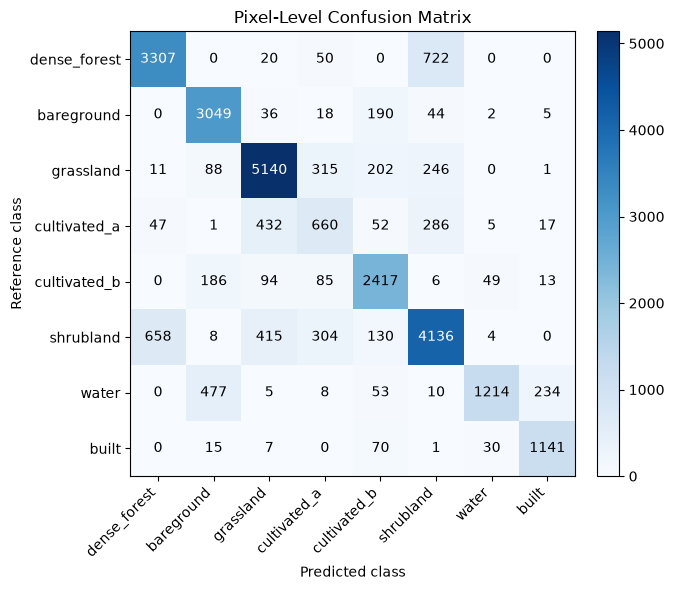

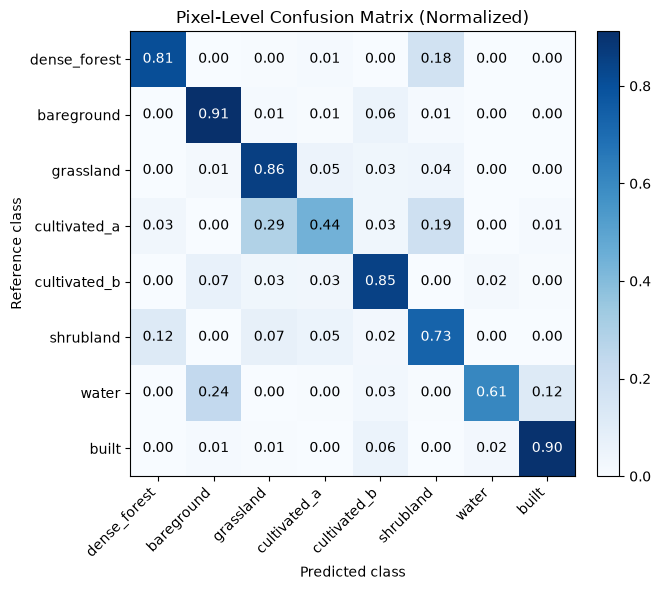

In [20]:
cm_pixels = compute_confusion_matrix(y_test, y_pred, CLASS_ORDER)
class_names = [CLASS_LABELS[c] for c in CLASS_ORDER]

confusion_matrix_frame(cm_pixels, CLASS_ORDER, CLASS_LABELS).to_csv(
    OUTPUT_DIR / "confusion_matrix_pixels.csv"
)
plot_confusion_matrix(
    cm_pixels, class_names, "Pixel-Level Confusion Matrix", OUTPUT_DIR / "confusion_matrix_pixels.png"
)
plot_confusion_matrix(
    cm_pixels, class_names, "Pixel-Level Confusion Matrix (Normalized)",
    OUTPUT_DIR / "normalized_confusion_matrix.png", normalize=True,
)

## 10. Calculate Accuracy Statistics

In [21]:
def compute_accuracy_metrics(y_true, y_pred, class_order, class_labels):
    """Producer's accuracy == recall; user's accuracy == precision (see plan Sec.10)."""
    overall_accuracy = float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))
    kappa = float(cohen_kappa_score(y_true, y_pred, labels=class_order))

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=class_order, zero_division=0
    )

    table = pd.DataFrame({
        "class_id": class_order,
        "class_name": [class_labels[c] for c in class_order],
        "producers_accuracy": recall,
        "users_accuracy": precision,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": support,
    })
    summary = {"overall_accuracy": overall_accuracy, "cohens_kappa": kappa}
    return table, summary

In [22]:
accuracy_table_pixels, accuracy_summary_pixels = compute_accuracy_metrics(
    y_test, y_pred, CLASS_ORDER, CLASS_LABELS
)
accuracy_table_pixels.to_csv(OUTPUT_DIR / "accuracy_metrics_pixels.csv", index=False)

print(f"Pixel-level overall accuracy: {accuracy_summary_pixels['overall_accuracy']:.4f}")
print(f"Pixel-level Cohen's kappa:    {accuracy_summary_pixels['cohens_kappa']:.4f}")
accuracy_table_pixels

Pixel-level overall accuracy: 0.7884
Pixel-level Cohen's kappa:    0.7489


,class_id,class_name,producers_accuracy,users_accuracy,precision,recall,f1_score,support
0,1,dense_forest,0.806782,0.822023,0.822023,0.806782,0.814331,4099
1,2,bareground,0.911782,0.797333,0.797333,0.911782,0.850725,3344
2,3,grassland,0.856239,0.835908,0.835908,0.856239,0.845951,6003
3,4,cultivated_a,0.440000,0.458333,0.458333,0.440000,0.448980,1500
4,5,cultivated_b,0.848070,0.776172,0.776172,0.848070,0.810530,2850
5,6,shrubland,0.731388,0.758760,0.758760,0.731388,0.744823,5655
6,7,water,0.606697,0.930982,0.930982,0.606697,0.734644,2001
7,8,built,0.902690,0.808646,0.808646,0.902690,0.853084,1264


## 11. Assess Accuracy at the Polygon Level

In [23]:
def polygon_level_assessment(test_results, class_order, class_labels):
    """Collapse each held-out polygon to its majority-predicted class before scoring, since
    pixels inside a polygon are spatially correlated and would otherwise inflate accuracy."""
    majority = (
        test_results.groupby("sample_id")
        .agg(y_true=("y_true", "first"), y_pred=("y_pred", lambda s: s.value_counts().idxmax()))
        .reset_index()
    )
    cm = compute_confusion_matrix(majority["y_true"], majority["y_pred"], class_order)
    table, summary = compute_accuracy_metrics(majority["y_true"], majority["y_pred"], class_order, class_labels)
    return majority, cm, table, summary

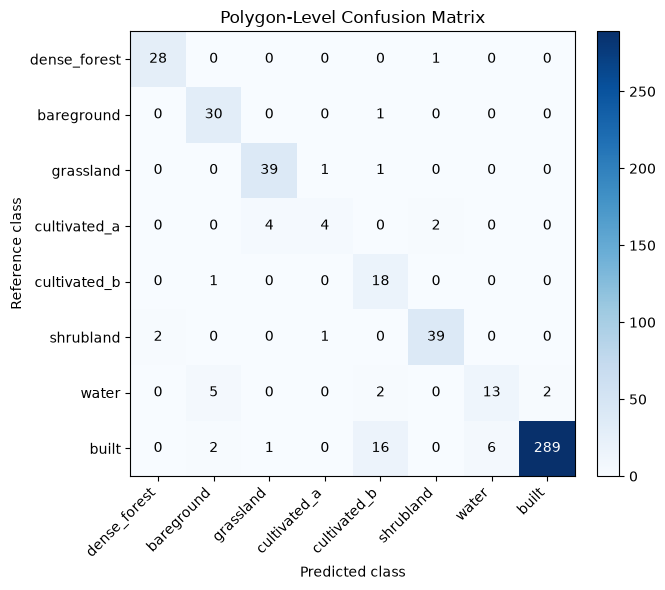

Polygon-level overall accuracy: 0.9055
Polygon-level Cohen's kappa:    0.8475


,class_id,class_name,producers_accuracy,users_accuracy,precision,recall,f1_score,support
0,1,dense_forest,0.965517,0.933333,0.933333,0.965517,0.949153,29
1,2,bareground,0.967742,0.789474,0.789474,0.967742,0.869565,31
2,3,grassland,0.951220,0.886364,0.886364,0.951220,0.917647,41
3,4,cultivated_a,0.400000,0.666667,0.666667,0.400000,0.500000,10
4,5,cultivated_b,0.947368,0.473684,0.473684,0.947368,0.631579,19
5,6,shrubland,0.928571,0.928571,0.928571,0.928571,0.928571,42
6,7,water,0.590909,0.684211,0.684211,0.590909,0.634146,22
7,8,built,0.920382,0.993127,0.993127,0.920382,0.955372,314


In [24]:
majority_predictions, cm_polygons, accuracy_table_polygons, accuracy_summary_polygons = (
    polygon_level_assessment(test_results, CLASS_ORDER, CLASS_LABELS)
)

confusion_matrix_frame(cm_polygons, CLASS_ORDER, CLASS_LABELS).to_csv(
    OUTPUT_DIR / "confusion_matrix_polygons.csv"
)
plot_confusion_matrix(
    cm_polygons, class_names, "Polygon-Level Confusion Matrix", OUTPUT_DIR / "confusion_matrix_polygons.png"
)
accuracy_table_polygons.to_csv(OUTPUT_DIR / "accuracy_metrics_polygons.csv", index=False)

print(f"Polygon-level overall accuracy: {accuracy_summary_polygons['overall_accuracy']:.4f}")
print(f"Polygon-level Cohen's kappa:    {accuracy_summary_polygons['cohens_kappa']:.4f}")
accuracy_table_polygons

Pixel-level and polygon-level accuracy are both reported above. A pixel-level accuracy that is notably higher than the polygon-level accuracy suggests large or internally uniform polygons are inflating the pixel-level score.

## 12. Review Classification Performance

In [25]:
LOW_ACCURACY_THRESHOLD = 0.75
MIN_SUPPORT = 30

low_producers = accuracy_table_pixels[accuracy_table_pixels["producers_accuracy"] < LOW_ACCURACY_THRESHOLD]
low_users = accuracy_table_pixels[accuracy_table_pixels["users_accuracy"] < LOW_ACCURACY_THRESHOLD]
low_support = accuracy_table_pixels[accuracy_table_pixels["support"] < MIN_SUPPORT]

print("Classes with low producer's accuracy (omission error):")
print(low_producers[["class_name", "producers_accuracy"]].to_string(index=False))
print()
print("Classes with low user's accuracy (commission error):")
print(low_users[["class_name", "users_accuracy"]].to_string(index=False))
print()
print("Classes with small test support:")
print(low_support[["class_name", "support"]].to_string(index=False))

Classes with low producer's accuracy (omission error):
  class_name  producers_accuracy
cultivated_a            0.440000
   shrubland            0.731388
       water            0.606697

Classes with low user's accuracy (commission error):
  class_name  users_accuracy
cultivated_a        0.458333

Classes with small test support:
Empty DataFrame
Columns: [class_name, support]
Index: []


In [26]:
# Top off-diagonal (reference, predicted) confusions, pixel-level.
cm_frame = confusion_matrix_frame(cm_pixels, CLASS_ORDER, CLASS_LABELS)
off_diagonal_values = cm_frame.to_numpy().copy()
np.fill_diagonal(off_diagonal_values, 0)
off_diagonal = pd.DataFrame(off_diagonal_values, index=cm_frame.index, columns=cm_frame.columns)
top_confusions = (
    off_diagonal.stack().rename("count").sort_values(ascending=False).head(10).reset_index()
)
print("Most common class confusions (pixel-level):")
top_confusions

Most common class confusions (pixel-level):


,reference,predicted,count
0,dense_forest,shrubland,722
1,shrubland,dense_forest,658
2,water,bareground,477
3,cultivated_a,grassland,432
4,shrubland,grassland,415
5,grassland,cultivated_a,315
6,shrubland,cultivated_a,304
7,cultivated_a,shrubland,286
8,grassland,shrubland,246
9,water,built,234


In [27]:
misclassified_polygons = majority_predictions[majority_predictions["y_true"] != majority_predictions["y_pred"]].copy()
misclassified_polygons["true_class_name"] = misclassified_polygons["y_true"].map(CLASS_LABELS)
misclassified_polygons["pred_class_name"] = misclassified_polygons["y_pred"].map(CLASS_LABELS)
print(f"{len(misclassified_polygons)} of {len(majority_predictions)} test polygons misclassified at majority vote:")
misclassified_polygons[["sample_id", "true_class_name", "pred_class_name"]]

48 of 508 test polygons misclassified at majority vote:


,sample_id,true_class_name,pred_class_name
2,bareground_1617,bareground,cultivated_b
57,built_0120,built,cultivated_b
68,built_0178,built,bareground
86,built_0301,built,grassland
97,built_0396,built,water
110,built_0440,built,cultivated_b
177,built_0785,built,cultivated_b
178,built_0789,built,cultivated_b
181,built_0805,built,cultivated_b
183,built_0812,built,cultivated_b


Pay particular attention to likely confusion between `cultivated_a`/`cultivated_b` (the two cultivated subclasses are collapsed into one `cultivated` class in the delivered map in Step 15, but confusion between them at this stage still means confusion with whatever they're each individually confused with), `bareground`/`cultivated_b` (harvested/bare cropland), `grassland`/low-density `shrubland`, `dense_forest`/dense `shrubland`, and `built`/bright bare surfaces.

Do not add these misclassified test polygons to the training set. If a class needs improvement, add new independent training polygons from underrepresented conditions and repeat the grouped assessment from Step 6 onward.

## 13. Save the Trained Model and Metadata

In [28]:
joblib.dump(model, OUTPUT_DIR / "random_forest_model.joblib")

feature_importance = pd.DataFrame(
    {"band": FEATURE_COLUMNS, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)
feature_importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

metadata = {
    "class_lookup": CLASS_LABELS,
    "final_class_lookup": FINAL_CLASS_LABELS,
    "class_remap": CLASS_REMAP,
    "predictor_bands": FEATURE_COLUMNS,
    "raster_nodata": RASTER_NODATA,
    "classification_nodata": CLASSIFICATION_NODATA,
    "random_forest_params": RF_PARAMS,
    "random_seed": RANDOM_SEED,
    "max_pixels_per_polygon": MAX_PIXELS_PER_POLYGON,
    "test_fraction": TEST_FRACTION,
    "n_training_pixels": int(len(y_train)),
    "n_training_polygons": int(train_df["sample_id"].nunique()),
    "n_test_pixels": int(len(y_test)),
    "n_test_polygons": int(test_df["sample_id"].nunique()),
    "pixel_accuracy": accuracy_summary_pixels,
    "polygon_accuracy": accuracy_summary_polygons,
    "source_raster_path": str(AIRBUS_RASTER_PATH),
    "training_layer_path": str(TRAINING_GPKG_PATH),
    "training_layer_name": TRAINING_LAYER,
}

with open(OUTPUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'class_lookup': {1: 'dense_forest',
  2: 'bareground',
  3: 'grassland',
  4: 'cultivated_a',
  5: 'cultivated_b',
  6: 'shrubland',
  7: 'water',
  8: 'built'},
 'final_class_lookup': {1: 'dense_forest',
  2: 'bareground',
  3: 'grassland',
  4: 'cultivated',
  5: 'shrubland',
  6: 'water',
  7: 'built'},
 'class_remap': {1: 1, 2: 2, 3: 3, 4: 4, 5: 4, 6: 5, 7: 6, 8: 7},
 'predictor_bands': ['band_1', 'band_2', 'band_3', 'band_4'],
 'raster_nodata': 65535,
 'classification_nodata': 255,
 'random_forest_params': {'n_estimators': 500,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'class_weight': 'balanced_subsample',
  'n_jobs': -1,
  'random_state': 42},
 'random_seed': 42,
 'max_pixels_per_polygon': 150,
 'test_fraction': 0.2,
 'n_training_pixels': 108308,
 'n_training_polygons': 2034,
 'n_test_pixels': 26716,
 'n_test_polygons': 508,
 'pixel_accuracy': {'overall_accuracy': 0.7884413834406349,
  'cohens_kappa': 0.7488799439159096},
 'polygon_accuracy': {'overall_accuracy': 0.90

## 14. Classify the Full Airbus Raster

This predicts the full-resolution training/model schema (`CLASS_LABELS`, with separate `cultivated_a`/`cultivated_b` classes). Step 15 below collapses it to the delivered schema.

In [29]:
def classify_raster_windowed(raster_path, model, output_nodata, nodata_value, output_path, tile_size=1024):
    """Predict the full raster block-by-block so the whole 1 m scene is never loaded into memory."""
    with rasterio.open(raster_path) as src:
        profile = src.profile.copy()
        profile.update(
            count=1,
            dtype="uint8",
            nodata=output_nodata,
            compress="deflate",
            tiled=True,
            blockxsize=256,
            blockysize=256,
        )

        with rasterio.open(output_path, "w", **profile) as dst:
            for row_off in range(0, src.height, tile_size):
                for col_off in range(0, src.width, tile_size):
                    window = rasterio.windows.Window(
                        col_off,
                        row_off,
                        min(tile_size, src.width - col_off),
                        min(tile_size, src.height - row_off),
                    )
                    block = src.read(window=window)
                    bands, h, w = block.shape
                    flat = block.reshape(bands, -1).T

                    valid = ~np.any(flat == nodata_value, axis=1)
                    out_flat = np.full(flat.shape[0], output_nodata, dtype=np.uint8)
                    if valid.any():
                        preds = model.predict(flat[valid].astype(np.float32))
                        out_flat[valid] = preds.astype(np.uint8)

                    dst.write(out_flat.reshape(h, w), 1, window=window)

    logger.info("Wrote classified raster to %s", output_path)

In [30]:
raw_classified_raster_path = OUTPUT_DIR / "airbus_landcover_classification_1m_8class.tif"
classify_raster_windowed(
    AIRBUS_RASTER_PATH, model, CLASSIFICATION_NODATA, RASTER_NODATA, raw_classified_raster_path
)

2026-07-26 23:42:05,712 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_database: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:42:05,712 WARNING CPLE_AppDefined in The definition of projected CRS EPSG:32736 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


2026-07-26 23:42:05,712 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:42:05,759 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:42:11,460 INFO GDAL signalled an error: err_no=1, msg='PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.'


2026-07-26 23:56:40,781 INFO Wrote classified raster to /Users/chris/Repos/CERK/EnarauConservnacy/outputs/rf_airbus_classifier/airbus_landcover_classification_1m_8class.tif


## 15. Combine Cultivated Subclasses for the Delivered Classification

`cultivated_a` and `cultivated_b` were trained as separate classes so the model could distinguish them from bareground/shrubland more cleanly, but the delivered map should carry the same 7-class schema as before. Remap the raw 8-class raster to `FINAL_CLASS_LABELS` using `CLASS_REMAP` (classes 1-3 unchanged; 4 and 5 both become `cultivated` (4); 6, 7, 8 shift down to 5, 6, 7).

In [31]:
def build_class_remap_lut(class_remap, nodata_value):
    """A 256-entry lookup table for remapping a uint8 classification raster by value.
    Any value not in class_remap (including the NoData value itself) passes through as NoData
    -- there should be no other values in a raster produced by classify_raster_windowed."""
    lut = np.full(256, nodata_value, dtype=np.uint8)
    for source_class_id, final_class_id in class_remap.items():
        lut[source_class_id] = final_class_id
    return lut


def remap_classification_raster(raster_path, class_remap, nodata_value, output_path, tile_size=1024):
    """Apply a class-ID lookup table to a single-band categorical raster, block-by-block."""
    lut = build_class_remap_lut(class_remap, nodata_value)

    with rasterio.open(raster_path) as src:
        profile = src.profile.copy()
        with rasterio.open(output_path, "w", **profile) as dst:
            for row_off in range(0, src.height, tile_size):
                for col_off in range(0, src.width, tile_size):
                    window = rasterio.windows.Window(
                        col_off,
                        row_off,
                        min(tile_size, src.width - col_off),
                        min(tile_size, src.height - row_off),
                    )
                    block = src.read(1, window=window)
                    dst.write(lut[block], 1, window=window)

    logger.info("Wrote combined-class raster to %s", output_path)

In [32]:
classified_raster_path = OUTPUT_DIR / "airbus_landcover_classification_1m.tif"
remap_classification_raster(
    raw_classified_raster_path, CLASS_REMAP, CLASSIFICATION_NODATA, classified_raster_path
)

2026-07-26 23:56:40,832 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:56:40,879 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


/var/folders/lq/7zmylls52_x6kpcbwqd90t0h0000gn/T/ipykernel_97745/3311495697.py:26: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  block = src.read(1, window=window)
2026-07-26 23:56:40,907 INFO GDAL signalled an error: err_no=1, msg='PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.'


2026-07-26 23:56:52,116 INFO Wrote combined-class raster to /Users/chris/Repos/CERK/EnarauConservnacy/outputs/rf_airbus_classifier/airbus_landcover_classification_1m.tif


## 16. Burn Known Cultivated Areas into the Combined Raster

`cultivated_poly.gpkg` delineates known/ground-truthed cultivated areas. Force those pixel locations to the delivered `cultivated` class, overriding whatever the model predicted there. This updates `classified_raster_path` in place, before overviews are built, so the overviews and Step 19 inspection reflect the corrected raster.

In [33]:
CULTIVATED_POLY_PATH = Path(
    "/Users/chris/Desktop/Projects/CERK/Enerau/enarau_hab_class/cultivated_poly.gpkg"
)


def class_id_for_name(class_labels, name):
    matches = [class_id for class_id, class_name in class_labels.items() if class_name == name]
    if not matches:
        raise ValueError(f"No class_id found for class_name={name!r}")
    return matches[0]


def burn_class_by_polygon(raster_path, polygon_path, class_id, nodata_value, tile_size=1024):
    """Force pixels covered by polygon_path to class_id, in place. NoData pixels are left
    untouched -- there's no valid classification underneath a masked/cloud area to override."""
    burn_gdf = gpd.read_file(polygon_path)

    with rasterio.open(raster_path, "r+") as dst:
        if burn_gdf.crs != dst.crs:
            logger.warning(
                "Reprojecting %s from %s to raster CRS %s", polygon_path, burn_gdf.crs, dst.crs
            )
            burn_gdf = burn_gdf.to_crs(dst.crs)

        geometries = [geom for geom in burn_gdf.geometry if geom is not None and not geom.is_empty]
        if not geometries:
            logger.warning("No valid geometries found in %s; nothing burned", polygon_path)
            return

        n_burned = 0
        for row_off in range(0, dst.height, tile_size):
            for col_off in range(0, dst.width, tile_size):
                window = rasterio.windows.Window(
                    col_off,
                    row_off,
                    min(tile_size, dst.width - col_off),
                    min(tile_size, dst.height - row_off),
                )
                win_transform = rasterio.windows.transform(window, dst.transform)
                mask = rasterize(
                    [(geom, 1) for geom in geometries],
                    out_shape=(int(window.height), int(window.width)),
                    transform=win_transform,
                    fill=0,
                    all_touched=False,
                    dtype="uint8",
                ).astype(bool)

                if not mask.any():
                    continue

                block = dst.read(1, window=window)
                burn_mask = mask & (block != nodata_value)
                if burn_mask.any():
                    block[burn_mask] = class_id
                    dst.write(block, 1, window=window)
                    n_burned += int(burn_mask.sum())

    logger.info(
        "Burned class %d into %s using %s (%d pixels)", class_id, raster_path, polygon_path, n_burned
    )

In [34]:
cultivated_class_id = class_id_for_name(FINAL_CLASS_LABELS, "cultivated")
burn_class_by_polygon(
    classified_raster_path, CULTIVATED_POLY_PATH, cultivated_class_id, CLASSIFICATION_NODATA
)

2026-07-26 23:56:52,176 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


/var/folders/lq/7zmylls52_x6kpcbwqd90t0h0000gn/T/ipykernel_97745/1945488266.py:52: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  block = dst.read(1, window=window)
/var/folders/lq/7zmylls52_x6kpcbwqd90t0h0000gn/T/ipykernel_97745/1945488266.py:52: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  block = dst.read(1, window=window)
/var/folders/lq/7zmylls52_x6kpcbwqd90t0h0000gn/T/ipykernel_97745/1945488266.py:52: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  block = dst.read(1, window=window)
/var/folders/lq/7zmylls52_x6kpcbwqd90t0h0000gn/T/ipykernel_97745/1945488266.py:52: DeprecationWarnin

2026-07-26 23:56:52,538 INFO Burned class 4 into /Users/chris/Repos/CERK/EnarauConservnacy/outputs/rf_airbus_classifier/airbus_landcover_classification_1m.tif using /Users/chris/Desktop/Projects/CERK/Enerau/enarau_hab_class/cultivated_poly.gpkg (2177472 pixels)


## 17. Resample the Final Raster to 10 m (Pixel Mode)

Downsample the delivered 1 m classification to 10 m using mode (majority-class) resampling -- appropriate for categorical data, unlike bilinear/cubic resampling which would blend class IDs into meaningless values.

In [35]:
def resample_categorical_raster(raster_path, output_path, target_resolution):
    """Downsample a categorical raster using mode (majority-class) resampling."""
    with rasterio.open(raster_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, src.crs, src.width, src.height, *src.bounds, resolution=target_resolution
        )
        profile = src.profile.copy()
        profile.update(
            transform=transform,
            width=width,
            height=height,
            compress="deflate",
            tiled=True,
            blockxsize=256,
            blockysize=256,
        )

        with rasterio.open(output_path, "w", **profile) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=src.crs,
                resampling=Resampling.mode,
            )

    logger.info("Wrote %sm resampled raster to %s", target_resolution, output_path)

In [36]:
classified_raster_10m_path = OUTPUT_DIR / "airbus_landcover_classification_10m.tif"
resample_categorical_raster(classified_raster_path, classified_raster_10m_path, target_resolution=10)

2026-07-26 23:56:52,583 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


2026-07-26 23:56:52,964 INFO GDAL signalled an error: err_no=1, msg='PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.'


2026-07-26 23:56:54,351 INFO Wrote 10m resampled raster to /Users/chris/Repos/CERK/EnarauConservnacy/outputs/rf_airbus_classifier/airbus_landcover_classification_10m.tif


## 18. Build Raster Overviews

In [37]:
def build_overviews(raster_path, factors=(2, 4, 8, 16, 32, 64, 128)):
    """Nearest-neighbor overviews, since the raster holds categorical classes (average
    resampling would blend class IDs into meaningless values)."""
    with rasterio.open(raster_path, "r+") as dst:
        dst.build_overviews(list(factors), Resampling.nearest)
        dst.update_tags(ns="rio_overview", resampling="nearest")

In [38]:
# Overviews are built on the delivered (combined-class, burned-in) raster, not the raw
# 8-class intermediate -- the combined raster is what gets loaded in QGIS in Step 19.
build_overviews(classified_raster_path)

2026-07-26 23:56:54,396 WARNING CPLE_AppDefined in PROJ: internal_proj_create_from_name: /Applications/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


## 19. Inspect the Final Classification

Manual step: load `airbus_landcover_classification_1m.tif` in QGIS with a fixed class color table (`FINAL_CLASS_LABELS` above) and inspect:

- class boundaries;
- cloud-mask and original NoData areas;
- salt-and-pepper noise;
- systematic confusion consistent with the Step 12 review;
- isolated implausible pixels;
- agricultural and built-up areas;
- performance across the full spatial extent.

Do not apply smoothing before this unsmoothed accuracy assessment is accepted. Any post-classification filtering (e.g. majority filter) must be documented and evaluated separately from the metrics computed above.

## Outputs

All outputs are written to `config.RF_CLASSIFIER_DIR`:

```text
training_sample_inventory.csv
sample_split.csv
random_forest_model.joblib
model_metadata.json
confusion_matrix_pixels.csv
confusion_matrix_pixels.png
confusion_matrix_polygons.csv
confusion_matrix_polygons.png
accuracy_metrics_pixels.csv
accuracy_metrics_polygons.csv
airbus_landcover_classification_1m_8class.tif  (raw model output, cultivated_a/b separate)
airbus_landcover_classification_1m.tif  (delivered map, cultivated_a/b combined, cultivated_poly.gpkg burned in)
airbus_landcover_classification_10m.tif  (10 m, mode-resampled from the delivered map)
normalized_confusion_matrix.png
feature_importance.csv
```

Accuracy metrics and confusion matrices are computed on the training/model schema (with separate `cultivated_a`/`cultivated_b`), since that's what the classifier actually predicts; they are not recomputed against the combined `cultivated` class.

`prediction_probability_rasters` (optional per the plan) is not produced -- per-class probability rasters for the full scene are a large additional export not required by any downstream step; add a variant of `classify_raster_windowed` that writes `model.predict_proba` per band if this is needed later.